In [1]:
# Import necessary libraries
import os
from ipywidgets import interact, widgets
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pyFAI
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
from pyFAI.gui import jupyter
import pyFAI.io
from pyFAI.io import image
from pyFAI.io.image import read_image_data
from pyFAI.detectors import Detector, Pilatus1M
from pyFAI.calibrant import CALIBRANT_FACTORY
# from pyFAI.calibration import Calibrator
from pyFAI.geometryRefinement import GeometryRefinement
import fabio

In [3]:
from sklearn.cluster import DBSCAN

## Integration

In [4]:
def display_saxs_tiff(file_path):
    """
    Display a 2D SAXS TIFF file with interactive controls using pyFAI.
    
    Parameters:
    file_path (str): Path to the TIFF file containing SAXS data
    """
    try:
        # Load the TIFF file
        saxs_data = image.read_image_data(file_path)

        fig, ax = plt.subplots()
        ax.hist(saxs_data[saxs_data < 100].flatten(), bins=100)
        plt.tight_layout()
        plt.show()

        # saxs_data = saxs_data - np.min(saxs_data)
        
        # Create a figure
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Display the image with logarithmic scaling by default
        im = ax.imshow(np.log1p(saxs_data), cmap='viridis', origin='lower')
        plt.colorbar(im, ax=ax, label='Log(Intensity + 1)')
        ax.set_title(f"2D SAXS Data: {os.path.basename(file_path)}")
        ax.set_xlabel("Pixel X")
        ax.set_ylabel("Pixel Y")
        
        plt.tight_layout()
        plt.show()
        
        # Add interactive controls
        print("\nInteractive Controls:")
        def update_plot(scale='log', cmap='viridis', vmin=None, vmax=None):
            fig, ax = plt.subplots(figsize=(10, 8))
            
            if scale == 'log':
                data = np.log1p(saxs_data)
                label = 'Log(Intensity + 1)'
            elif scale == 'sqrt':
                data = np.sqrt(saxs_data)
                label = '√Intensity'
            else:  # linear
                data = saxs_data
                label = 'Intensity'
            
            im = ax.imshow(data, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=ax, label=label)
            ax.set_title(f"2D SAXS Data: {os.path.basename(file_path)}")
            ax.set_xlabel("Pixel X")
            ax.set_ylabel("Pixel Y")
            plt.tight_layout()
            plt.show()
        
        # Calculate reasonable default vmin/vmax based on 1st and 99th percentiles
        data_nonzero = saxs_data[saxs_data > 0]
        if len(data_nonzero) > 0:
            def_vmin = np.percentile(data_nonzero, 1)
            def_vmax = np.percentile(data_nonzero, 99)
        else:
            def_vmin = None
            def_vmax = None
        
        interact(update_plot,
                 scale=widgets.Dropdown(options=['log', 'sqrt', 'linear'], value='log', description='Scaling:'),
                 cmap=widgets.Dropdown(options=['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'jet', 'hot', 'cool'], 
                                      value='viridis', description='Colormap:'),
                 vmin=widgets.FloatSlider(min=0, max=def_vmax if def_vmax else 100, step=0.1, 
                                        value=def_vmin if def_vmin else 0, description='Min value:'),
                 vmax=widgets.FloatSlider(min=0, max=def_vmax*2 if def_vmax else 200, step=0.1, 
                                        value=def_vmax if def_vmax else 100, description='Max value:'))
        
    except Exception as e:
        print(f"Error loading or displaying the file: {e}")


In [5]:
def display_saxs_tiff_simple(tiffpath, scale='log', cmap='viridis', plotFilePath=None):
    # Load the TIFF file
    saxs_data = image.read_image_data(tiffpath)

    # fig, ax = plt.subplots()
    # ax.hist(saxs_data[saxs_data < 100].flatten(), bins=100)
    # plt.tight_layout()
    # plt.show()

    # saxs_data = saxs_data - np.min(saxs_data)

    if scale == 'log':
        plot_data = np.log1p(saxs_data)
        color_label = 'Log(Intensity + 1)'
    elif scale == 'sqrt':
        plot_data = np.sqrt(saxs_data)
        color_label = '√Intensity'
    elif scale == 'linear':
        plot_data = saxs_data
        color_label = 'Intensity'
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Display the image with logarithmic scaling by default
    im = ax.imshow(plot_data, cmap=cmap, origin='lower')
    fig.colorbar(im, ax=ax, label=color_label)
    ax.set_title(f"2D SAXS Data: {os.path.basename(tiffpath)}")
    ax.set_xlabel("Pixel X")
    ax.set_ylabel("Pixel Y")

    if plotFilePath is not None:
        fig.savefig(plotFilePath)

/tmp/ipykernel_27695/1261885941.py:13: RuntimeWarning: divide by zero encountered in log1p
  plot_data = np.log1p(saxs_data)
/tmp/ipykernel_27695/1261885941.py:13: RuntimeWarning: invalid value encountered in log1p
  plot_data = np.log1p(saxs_data)


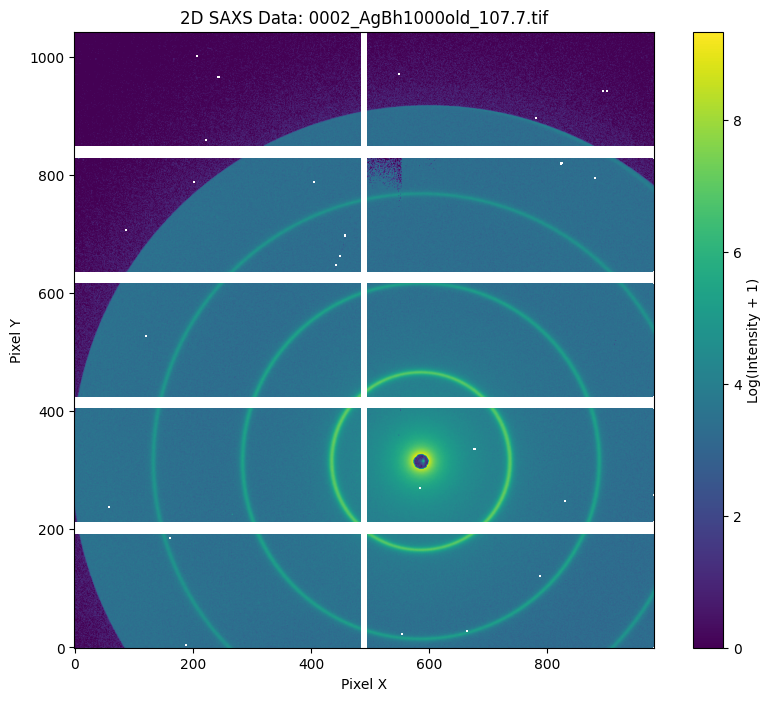

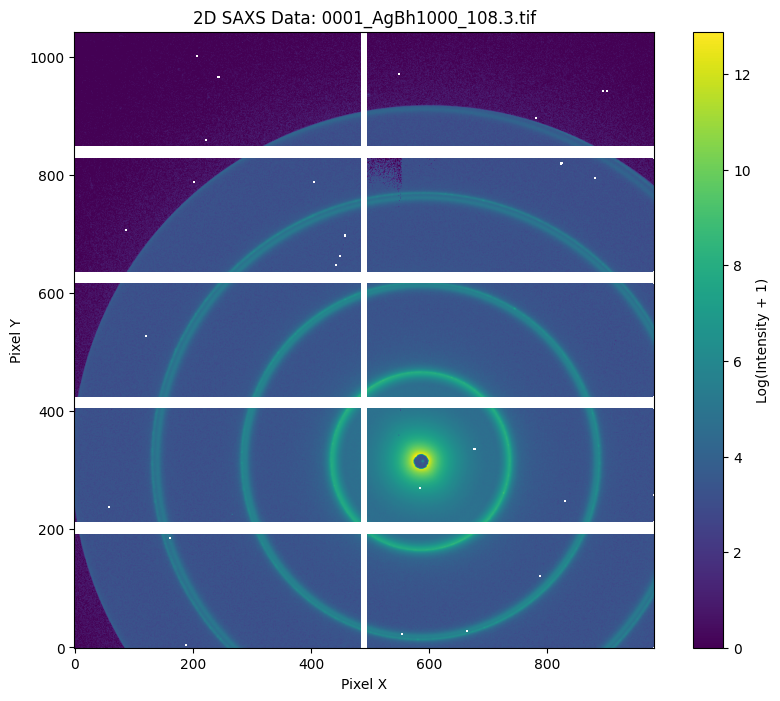

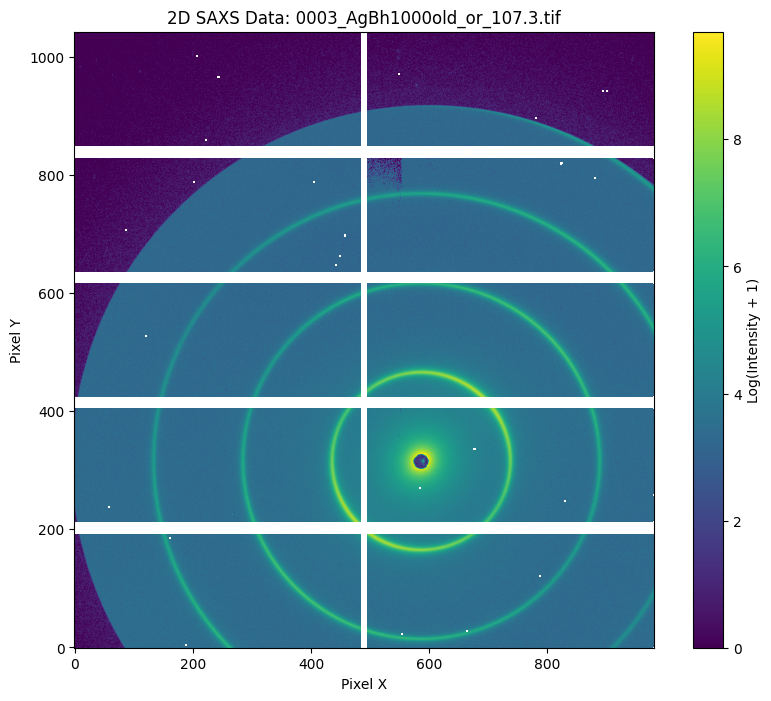

In [7]:
folder = '../AgBh/100225_doubling/test'
for fn in filter(lambda p: os.path.splitext(p)[1] == '.tif', os.listdir(folder)):
    filepath = os.path.join(folder, fn)
    filename = os.path.splitext(fn)[0]
    display_saxs_tiff_simple(
        filepath, scale='log', plotFilePath=os.path.join(folder, f'{filename}.png'))

In [5]:
fabio_img = fabio.open('../AgBh/100225_doubling/test/0001_AgBh1000_108.3.tif')
fabio_img.header

{
  "Pixel_size": "172e-6 m x 172e-6 m",
  "Silicon": "sensor, thickness 0.000450 m",
  "Exposure_time": "60.0000000 s",
  "Exposure_period": "60.0000000 s",
  "Tau": "0 s",
  "Count_cutoff": "1053296 counts",
  "Threshold_setting": "4024 eV",
  "Gain_setting": "autog (vrf = 1.000)",
  "N_excluded_pixels": "71",
  "Excluded_pixels": "badpixel_mask.tif",
  "Flat_field": "FF_p10-0127_E8048_T4024_vrf_m0p100.tif",
  "Trim_file": "p10-0127_E8048_T4024.bin",
  "Image_path": "/ramdisk/2025/02/10-02-2025/test/",
  "Ratecorr_lut_directory": "ContinuousStandard_v1.1",
  "Retrigger_mode": "1"
}

In [6]:
fabio_img = fabio.open('../ihs/06-06-2025/cell/0001_AgBh700_96.9.tif')
fabio_img.header

{
  "Pixel_size": "172e-6 m x 172e-6 m",
  "Silicon": "sensor, thickness 0.000450 m",
  "Exposure_time": "60.0000000 s",
  "Exposure_period": "60.0000000 s",
  "Tau": "0 s",
  "Count_cutoff": "1053296 counts",
  "Threshold_setting": "4024 eV",
  "Gain_setting": "autog (vrf = 1.000)",
  "N_excluded_pixels": "71",
  "Excluded_pixels": "badpixel_mask.tif",
  "Flat_field": "FF_p10-0127_E8048_T4024_vrf_m0p100.tif",
  "Trim_file": "p10-0127_E8048_T4024.bin",
  "Image_path": "/home/det/images/2025/06/06-06-2025/cell/",
  "Ratecorr_lut_directory": "ContinuousStandard_v1.1",
  "Retrigger_mode": "1"
}

In [6]:
def read_chi(chi_path):
    data_lines = []
    header_passed = False
    
    with open(chi_path, 'r') as f:
        for line in f:
            # Skip empty lines and comment lines
            if not line.strip() or line.startswith('#'):
                continue
            
            # Check if we've passed the header (line with two float values)
            parts = line.split()
            if len(parts) == 2:
                try:
                    # Try converting both parts to floats
                    float(parts[0])
                    float(parts[1])
                    header_passed = True
                except ValueError:
                    pass
            
            # Only collect data lines after header is passed
            if header_passed and len(parts) == 2:
                data_lines.append(line)
    
    # Convert collected data lines to arrays
    if data_lines:
        q, I = np.loadtxt(data_lines, unpack=True)
        return q, I
    else:
        raise ValueError("No valid data found in .chi file")


In [7]:
def fit_circle(points):
    x = points[:, 0]
    y = points[:, 1]
    n = len(x)
    
    # Вычисление сумм
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x**2)
    sum_y2 = np.sum(y**2)
    sum_xy = np.sum(x * y)
    sum_x3 = np.sum(x**3)
    sum_y3 = np.sum(y**3)
    sum_x2y = np.sum(x**2 * y)
    sum_xy2 = np.sum(x * y**2)
    sum_x2_y2 = sum_x2 + sum_y2
    
    # Матрица системы
    A = np.array([
        [sum_x2, sum_xy, sum_x],
        [sum_xy, sum_y2, sum_y],
        [sum_x,  sum_y,  n]
    ])
    
    # Вектор правой части
    B = np.array([
        -(sum_x3 + sum_xy2),
        -(sum_y3 + sum_x2y),
        -sum_x2_y2
    ])
    
    # Решение системы
    c, d, e = np.linalg.solve(A, B)
    
    # Параметры окружности
    a = -c / 2
    b = -d / 2
    r = np.sqrt(a**2 + b**2 - e)
    
    return (a, b, r)

In [8]:
def find_beam_center(data, q_start=0.95, q_stop=0.995, min_segment_len=50):
    q0 = np.quantile(data, q_start)
    q1 = np.quantile(data, q_stop)
    idx = np.where((data > q0) & (data < q1))
    ring_pixels = np.transpose(np.vstack(idx))

    dbscan = DBSCAN(min_samples=10, eps=30.)
    cluster = dbscan.fit_predict(ring_pixels)

    ring_pixels = np.hstack([ring_pixels, cluster.reshape(-1, 1)])
    # plot_df = pd.DataFrame(data=ring_pixels, columns=['y', 'x', 'cluster'])
    
    # fig, ax = plt.subplots(figsize=(12, 12))
    # sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster', ax=ax)

    centers = []
    for c in np.unique(cluster):
        if c == -1:
            continue
        ring = ring_pixels[ring_pixels[:, 2] == c][:, [0, 1]]
        if len(ring) < min_segment_len:
            continue
        center_x, center_y, _ = fit_circle(ring)
        centers.append((center_x, center_y))

    center = np.median(centers, axis=0)

    return center

In [9]:
def compare_saxs_curves(tiff_path, mask_path,
                        int_params_update=None):
    """
    Process 2D SAXS data using calibration from TIFF header, 
    compare with reference curve, and save comparison plot
    
    Args:
        tiff_path: Path to input TIFF file with 2D SAXS data
    """
    
    # === REMOVE OLD PONI HANDLING ===
    # Instead, we'll load calibration from TIFF header
    
    # === NEW: LOAD TIFF WITH HEADER ===
    # Open TIFF file and read header
    fabio_img = fabio.open(tiff_path)
    saxs_2d = fabio_img.data
    header = fabio_img.header

    if any(p not in int_params_update for p in ['beam_x', 'beam_y']):
        center = find_beam_center(saxs_2d)  # custom center detection
        int_params_update['beam_x'] = center[1]
        int_params_update['beam_y'] = center[0]
    
    # Extract calibration parameters from header
    # (These keys are typical for Pilatus/Eiger detectors)
    int_params = dict(
        dist = float(header.get('distance', 0.75)),  # in meters
        wavelength = float(header.get('wavelength', 1e-10)),  # in meters
        beam_x = float(header.get('beam_x', saxs_2d.shape[1]/2)),  # in pixels
        beam_y = float(header.get('beam_y', saxs_2d.shape[0]/2)),  # in pixels
        pixel_size = float(header.get('pixel_size', 1e-4))  # in meters
    )
    if int_params_update is not None:
        int_params.update(int_params_update)

    pixel_size = int_params['pixel_size']
    del int_params['pixel_size']
    
    int_params['poni2'] = pixel_size * int_params['beam_x']
    int_params['poni1'] = pixel_size * int_params['beam_y']
    del int_params['beam_x']
    del int_params['beam_y']
    
    # === NEW: LOAD MASK FILE ===
    if mask_path is not None and os.path.exists(mask_path):
        mask = fabio.open(mask_path).data
        print(f"Using mask: {os.path.basename(mask_path)}")
    else:
        mask = None
        print("No mask file found - proceeding without mask")
    
    # Initialize azimuthal integrator with header calibration
    # detector = Detector(pixel_size, pixel_size)
    detector = Pilatus1M(pixel_size, pixel_size)
    ai = AzimuthalIntegrator(
        detector=detector,
        **int_params
    )
    
    # === THE REST REMAINS MOSTLY THE SAME ===
    # Determine reference .chi file path
    ref_chi_path = os.path.splitext(tiff_path)[0] + ".chi"
    if not os.path.exists(ref_chi_path):
        raise FileNotFoundError(f"Reference .chi file not found: {ref_chi_path}")
    
    # Perform azimuthal integration (NOW WITH MASK)
    result = ai.integrate1d(
        saxs_2d, 
        npt=500, 
        mask=mask,  # NEW: Apply mask if available
        # unit="q_A^-1",
        correctSolidAngle=True,
        polarization_factor=0.99
    )
    q_calc, I_calc = result
    
    # Load reference data
    q_ref, I_ref = read_chi(ref_chi_path)
    
    # Set Seaborn style
    sns.set_theme(style="whitegrid")
    sns.set_context("notebook", font_scale=1.2)
    
    # Create comparison plot
    plt.figure(figsize=(10, 6))
    
    # Plot both curves with different line styles
    plt.plot(q_ref, I_ref, 'b-', linewidth=2.5, label='Reference', alpha=0.8)
    plt.plot(q_calc, I_calc, 'r--', linewidth=2, label='Calculated')
    
    # Set logarithmic scales and labels
    plt.xscale('log')
    plt.yscale('log')
    # plt.xlabel("Scattering vector q ($\AA^{-1}$)", fontsize=14)
    plt.xlabel("Scattering vector q ($nm^{-1}$)", fontsize=14)
    plt.ylabel("Intensity (a.u.)", fontsize=14)
    
    # Add title and legend
    filename = os.path.basename(tiff_path)
    plt.title(f"SAXS Curve Comparison: {filename}", fontsize=16)
    plt.legend(fontsize=12)
    
    # Add grid and adjust layout
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save comparison plot
    save_path = os.path.splitext(tiff_path)[0] + "_comp.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Comparison plot saved to: {save_path}")
    return save_path

No mask file found - proceeding without mask


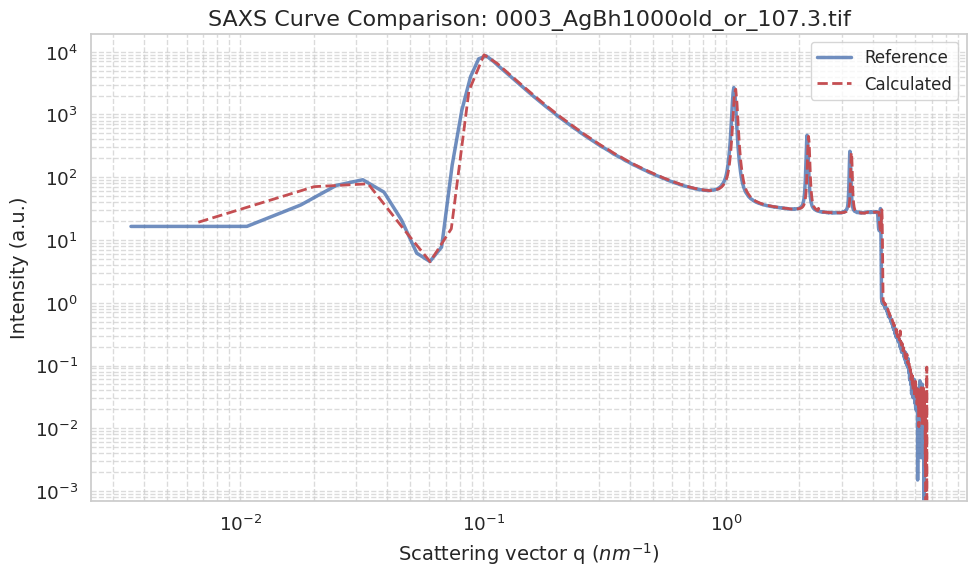

Comparison plot saved to: ../AgBh/100225_doubling/test/0003_AgBh1000old_or_107.3_comp.png


'../AgBh/100225_doubling/test/0003_AgBh1000old_or_107.3_comp.png'

In [77]:
compare_saxs_curves('../AgBh/100225_doubling/test/0003_AgBh1000old_or_107.3.tif', 
                    # '../AgBh/100225_doubling/test/fit2d_100225.msk',
                    None,
                    int_params_update=dict(
                        wavelength=1.445e-10,
                        # wavelength=1.e-10,
                        dist=0.6,
                        # pixel_size=1.72e-4,
                        # beam_x=587., beam_y=316.,
                    ))